## DATA PREPROCESSING & EXPLORATION

In [1]:
import pandas
import matplotlib.pyplot as plt
ds = pandas.read_csv('../data/denial_reason.csv')
#print(ds.head())
print("The Null values before cleaning:", ds.isnull().sum())
ds = ds.dropna(subset=['payer_name'])
ds = ds.fillna({'denial_text':'short_denial_summary'})


print("The Null values after cleaning:", ds.isnull().sum(),"\n")

print("The shape of the dataset is:", ds.shape, "\n")

print(ds.dtypes,"\n")

print("The description of the dataset is:", ds.describe(), "\n")

The Null values before cleaning: case_id                           0
payer_name                     3968
request_type                      0
diagnosis_category                0
service_code                      0
policy_id                         0
supporting_doc_count              0
missing_required_conditions       0
denial_text                    2939
short_denial_summary              0
policy_excerpt                    0
detailed_denial_reason            0
project_reason_class              0
dtype: int64
The Null values after cleaning: case_id                        0
payer_name                     0
request_type                   0
diagnosis_category             0
service_code                   0
policy_id                      0
supporting_doc_count           0
missing_required_conditions    0
denial_text                    0
short_denial_summary           0
policy_excerpt                 0
detailed_denial_reason         0
project_reason_class           0
dtype: int64 

The shape 

## Handling outliers

In [6]:
print(ds.missing_required_conditions.value_counts(), "\n")
#outliers detected in the missing required conditions soi removing them using IQR method
q1 = ds['missing_required_conditions'].quantile(0.25)
q3 = ds['missing_required_conditions'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
ds['missing_required_conditions'] = ds['missing_required_conditions'].clip(lower=lower, upper=upper)


print(ds["supporting_doc_count"].value_counts(), "\n")
# so no outliers in the supporting doc count column

missing_required_conditions
1.0    63376
2.0    50258
0.0    39786
3.0    26995
3.5    15617
Name: count, dtype: int64 

supporting_doc_count
0    22027
2    21947
5    21944
1    21817
3    21813
6    21768
8    21752
7    21667
4    21297
Name: count, dtype: int64 



## Numerical Data Representation

## BoxPlot of supporting document count

BoxPlot of the supporting doc count Axes(0.125,0.11;0.775x0.77) 



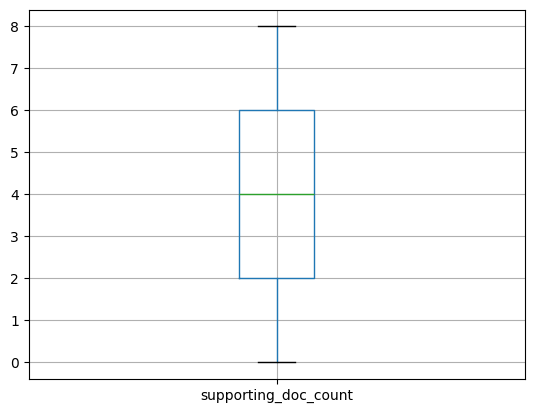

In [3]:
print("BoxPlot of the supporting doc count", ds.boxplot(column='supporting_doc_count'),"\n")

## BoxPlot of missing required conditions

In [7]:
print("BoxPlot of the missing required conditions after pruning", ds.boxplot(column='missing_required_conditions'),"\n")


BoxPlot of the missing required conditions after pruning Axes(0.125,0.11;0.775x0.77) 



## Histogram of missing required conditions

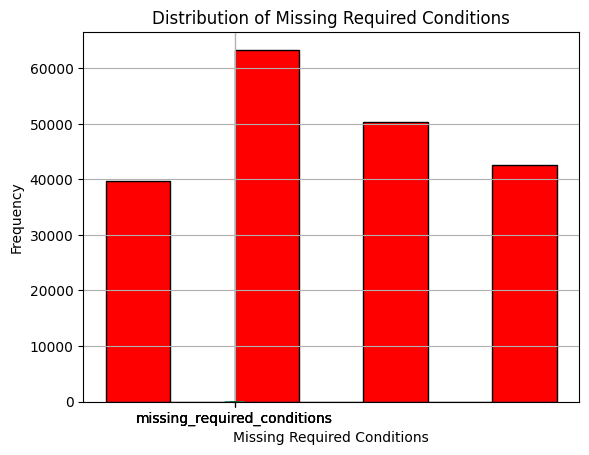

In [8]:
import matplotlib.pyplot as plt

plt.hist(ds['missing_required_conditions'], bins=7, edgecolor='black', color='red')
plt.xlabel('Missing Required Conditions')
plt.ylabel('Frequency')
plt.title('Distribution of Missing Required Conditions')
plt.show()

## Histogram for supporting document count

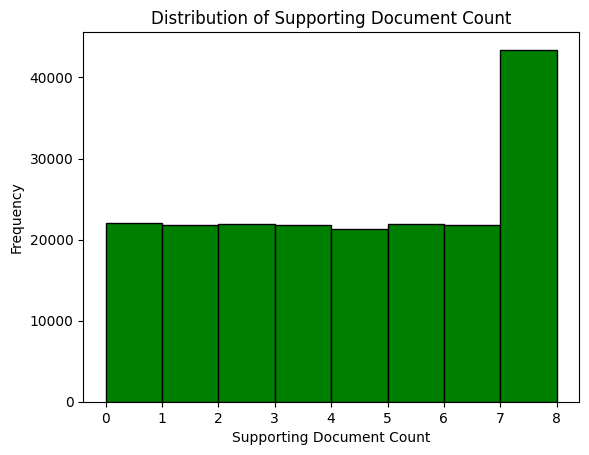

In [9]:
plt.hist(ds['supporting_doc_count'], bins=8, edgecolor='black', color='green')
plt.xlabel('Supporting Document Count')
plt.ylabel('Frequency')
plt.title('Distribution of Supporting Document Count')
plt.show()

## Scatter Plot between supporting document count & missing required conditions

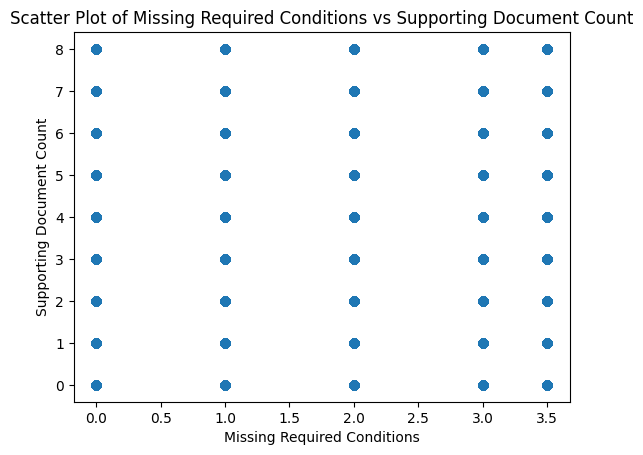

In [10]:
plt.scatter(ds['missing_required_conditions'], ds['supporting_doc_count'])
plt.xlabel('Missing Required Conditions')
plt.ylabel('Supporting Document Count')
plt.title('Scatter Plot of Missing Required Conditions vs Supporting Document Count')
plt.show()

#Seems to be no corelation between the two columns.

## Categorical Data Representation
## Bar Grpahs:

In [ ]:
denial_summary_dict = ds.short_denial_summary.value_counts().to_dict()
denial_text_dict = ds.denial_text.value_counts().to_dict()
project_reason_dict = ds.project_reason_class.value_counts().to_dict()
denial_reason_dict = ds.detailed_denial_reason.value_counts().to_dict()
policy_excerpt_dict = ds.policy_excerpt.value_counts().to_dict()
policy_id_dict = ds.policy_id.value_counts().to_dict()
service_code_dict = ds.service_code.value_counts().to_dict()
diagnosis_category_dict = ds.diagnosis_category.value_counts().to_dict()
request_type_dict = ds.request_type.value_counts().to_dict()
payer_name_dict = ds.payer_name.value_counts().to_dict()


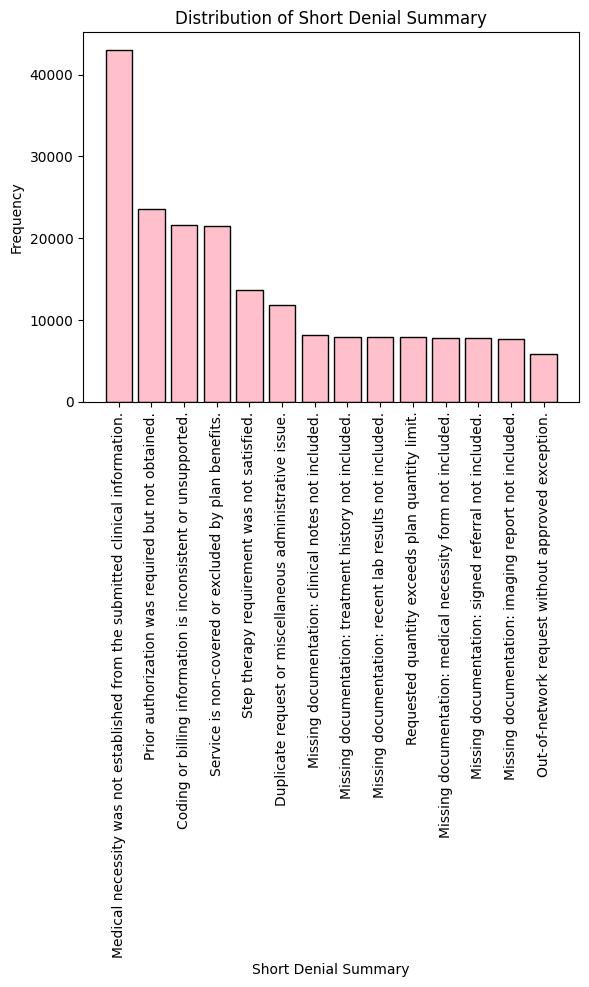

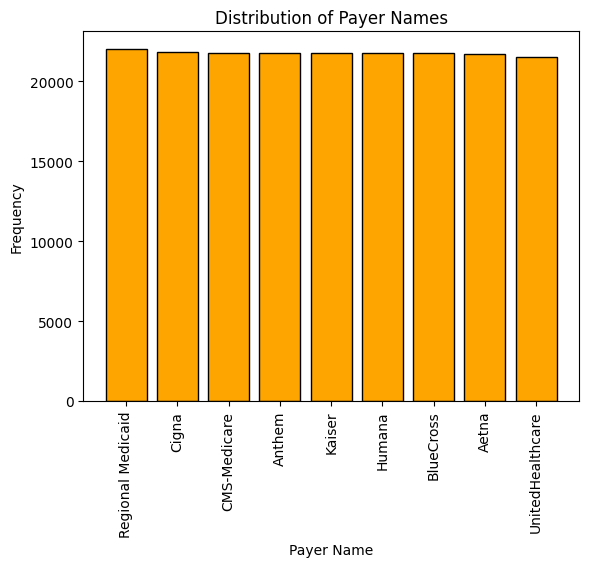

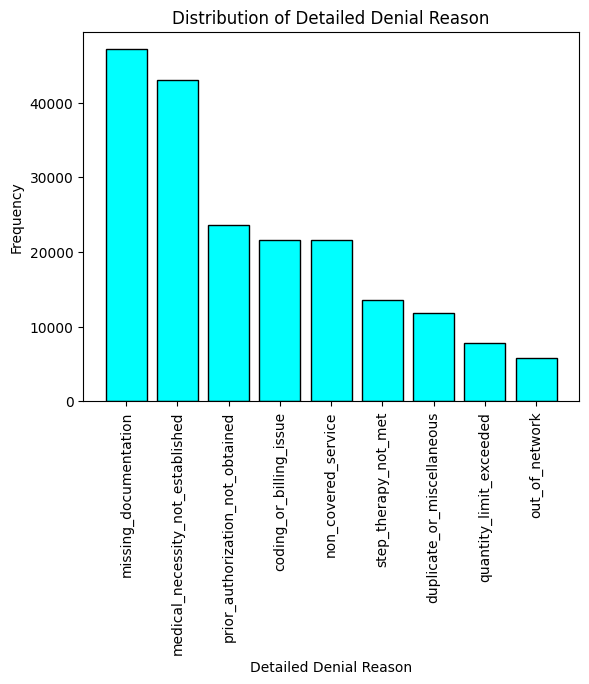

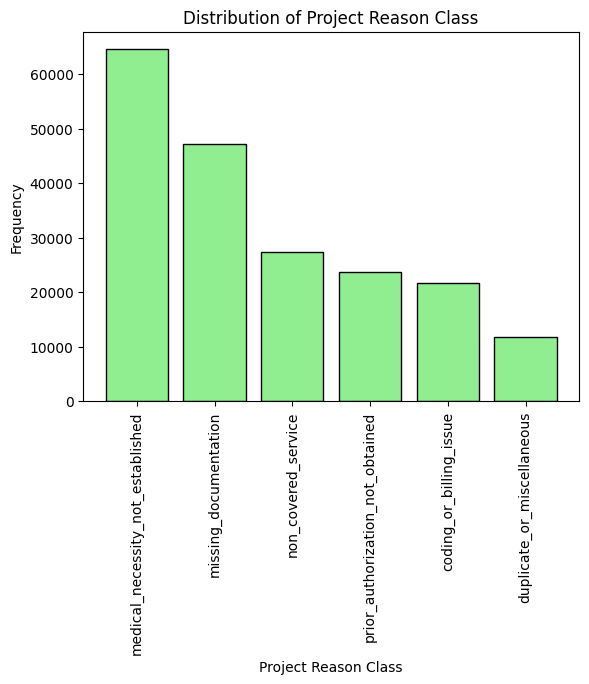

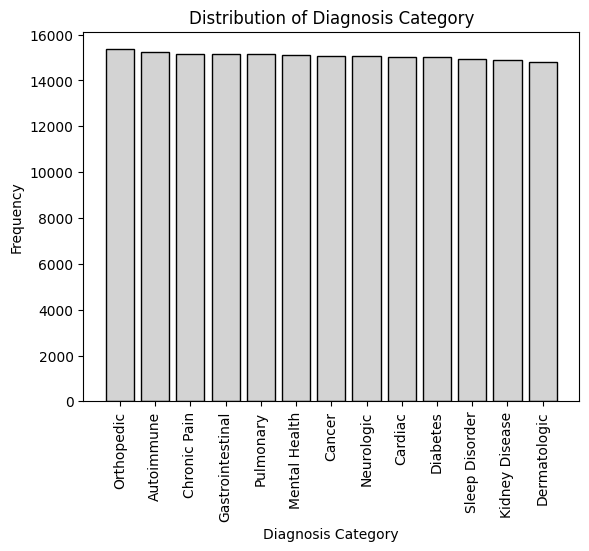

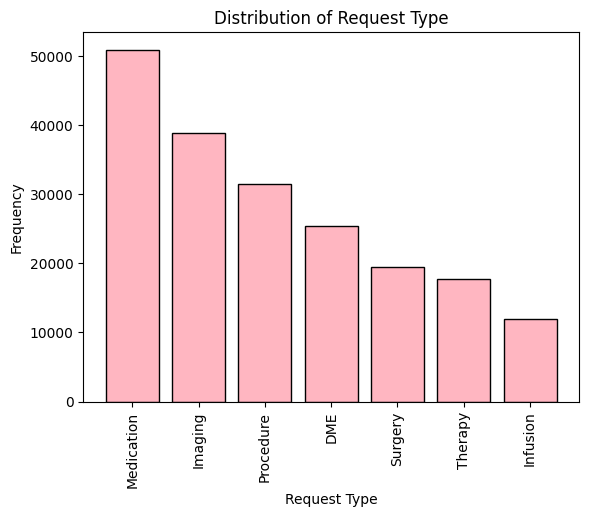

In [14]:
denial_summary_dict = ds.short_denial_summary.value_counts().to_dict()
project_reason_dict = ds.project_reason_class.value_counts().to_dict()
denial_reason_dict = ds.detailed_denial_reason.value_counts().to_dict()
diagnosis_category_dict = ds.diagnosis_category.value_counts().to_dict()
request_type_dict = ds.request_type.value_counts().to_dict()
payer_name_dict = ds.payer_name.value_counts().to_dict()

plt.bar(denial_summary_dict.keys(), denial_summary_dict.values(), color='pink', edgecolor='black')
plt.xlabel('Short Denial Summary')
plt.ylabel('Frequency')
plt.title('Distribution of Short Denial Summary')
plt.xticks(rotation=90)
plt.show()


plt.bar(payer_name_dict.keys(), payer_name_dict.values(), color='orange', edgecolor='black')
plt.xlabel('Payer Name')
plt.ylabel('Frequency')
plt.title('Distribution of Payer Names')
plt.xticks(rotation=90)
plt.show()


plt.bar(denial_reason_dict.keys(), denial_reason_dict.values(), color='cyan', edgecolor='black')
plt.xlabel('Detailed Denial Reason')
plt.ylabel('Frequency')
plt.title('Distribution of Detailed Denial Reason')
plt.xticks(rotation=90)
plt.show()


plt.bar(project_reason_dict.keys(), project_reason_dict.values(), color='lightgreen', edgecolor='black')
plt.xlabel('Project Reason Class')
plt.ylabel('Frequency')
plt.title('Distribution of Project Reason Class')
plt.xticks(rotation=90)
plt.show()

plt.bar(diagnosis_category_dict.keys(), diagnosis_category_dict.values(), color='lightgray', edgecolor='black')
plt.xlabel('Diagnosis Category')
plt.ylabel('Frequency')
plt.title('Distribution of Diagnosis Category')
plt.xticks(rotation=90)
plt.show()

plt.bar(request_type_dict.keys(), request_type_dict.values(), color='lightpink', edgecolor='black')
plt.xlabel('Request Type')
plt.ylabel('Frequency')
plt.title('Distribution of Request Type')
plt.xticks(rotation=90)
plt.show()

## Categorical Data Pie Charts

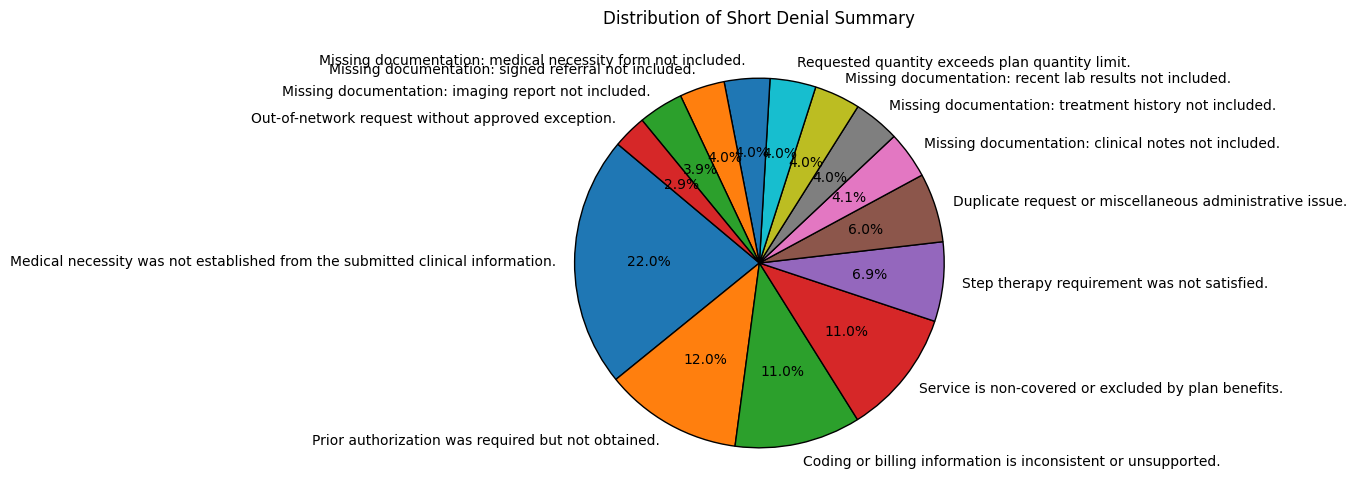

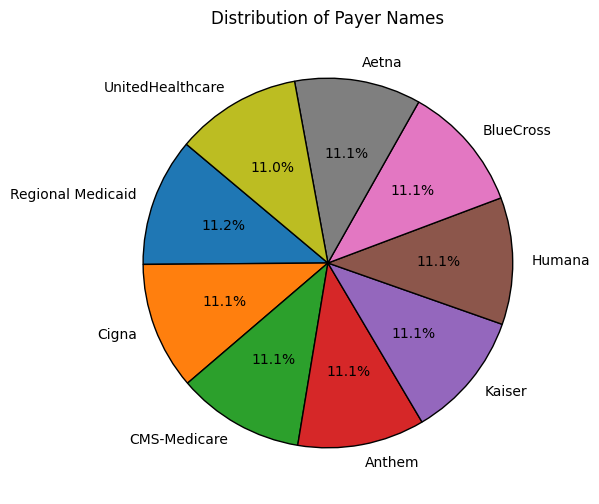

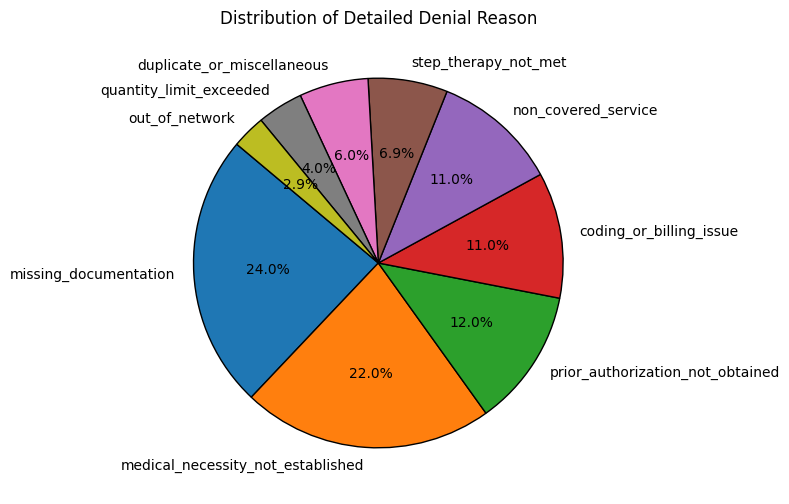

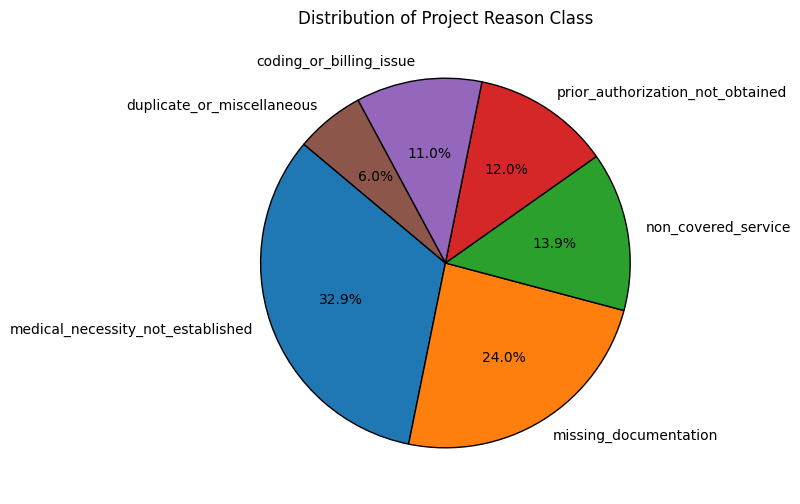

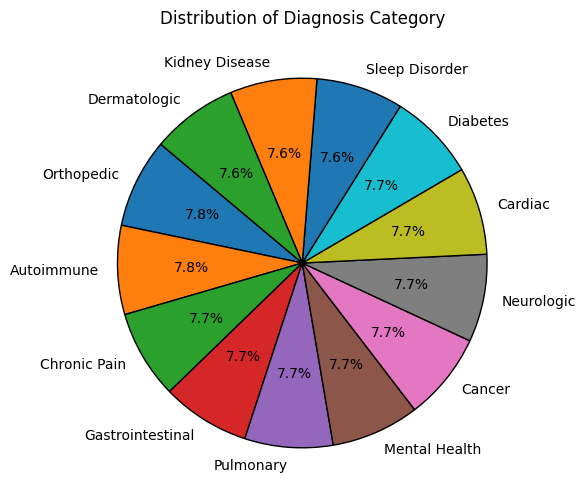

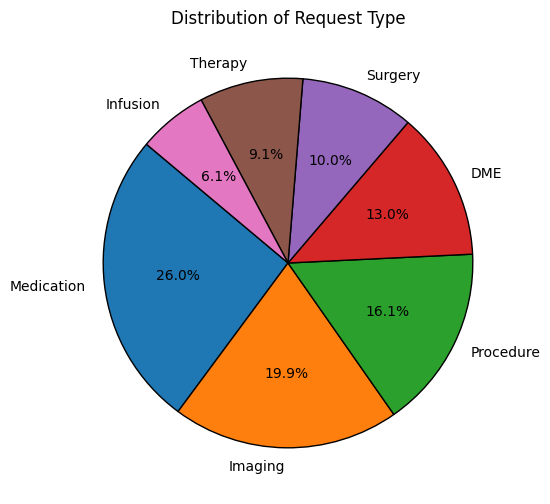

In [ ]:

# Short Denial Summary
plt.figure(figsize=(8,6))
plt.pie(denial_summary_dict.values(), labels=denial_summary_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Short Denial Summary')
plt.show()

# Payer Names
plt.figure(figsize=(8,6))
plt.pie(payer_name_dict.values(), labels=payer_name_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Payer Names')
plt.show()

# Detailed Denial Reason
plt.figure(figsize=(8,6))
plt.pie(denial_reason_dict.values(), labels=denial_reason_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Detailed Denial Reason')
plt.show()

# Project Reason Class
plt.figure(figsize=(8,6))
plt.pie(project_reason_dict.values(), labels=project_reason_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Project Reason Class')
plt.show()

# Diagnosis Category
plt.figure(figsize=(8,6))
plt.pie(diagnosis_category_dict.values(), labels=diagnosis_category_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Diagnosis Category')
plt.show()

# Request Type
plt.figure(figsize=(8,6))
plt.pie(request_type_dict.values(), labels=request_type_dict.keys(),
        autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'black'})
plt.title('Distribution of Request Type')
plt.show()


## Most Frequent Categorical Features

The categorical charts show that the most common short denial summary is **Medical necessity was not established from the submitted clinical information** with 43,878 records. For detailed denial reasons, **missing_documentation** is the most frequent category with 48,103 records, followed by **medical_necessity_not_established** with 43,878 records.

At the project reason class level, **medical_necessity_not_established** is the largest category with 65,847 records. The most frequent payer is **Regional Medicaid** with 22,022 records, though payer counts are fairly close across the top payers. For diagnosis categories, **Orthopedic** appears most often with 15,689 records, and for request types, **Medication** is the most common with 51,971 records.

## Pair Plot for Denial Reason

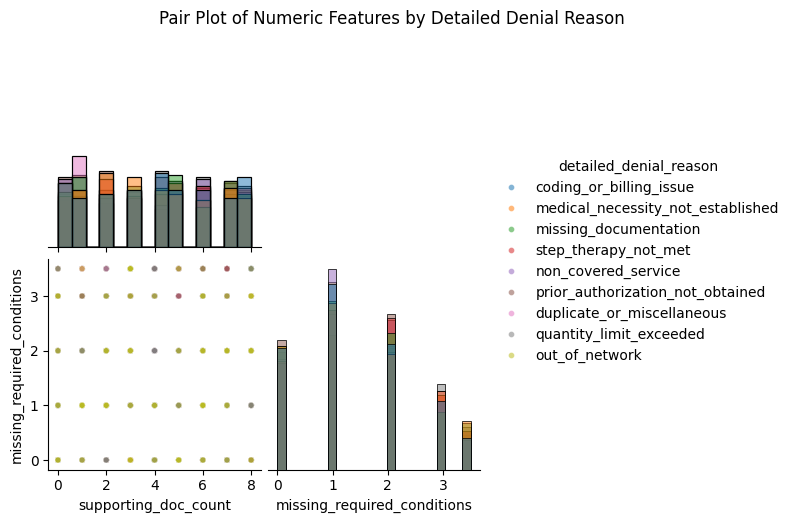

In [21]:
import seaborn as sns

pair_plot_features = ['supporting_doc_count', 'missing_required_conditions']
pair_plot_cols = pair_plot_features + ['detailed_denial_reason']

# Use a balanced sample per denial reason so the pair plot remains readable and fast.
# Shuffle first, then take up to 250 rows per class. This keeps the hue column intact.
pair_plot_data = ds[pair_plot_cols].dropna()
pair_plot_sample = (
    pair_plot_data
    .sample(frac=1, random_state=42)
    .groupby('detailed_denial_reason', group_keys=False)
    .head(250)
    .reset_index(drop=True)
)

sns.pairplot(
    pair_plot_sample,
    vars=pair_plot_features,
    hue='detailed_denial_reason',
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.55, 's': 18},
)
plt.suptitle('Pair Plot of Numeric Features by Detailed Denial Reason', y=1.03)
plt.show()
